In [356]:
import numpy as np
import pandas as pd

In [357]:
# 전력사용량 데이터 불러오기

import glob 

files = glob.glob('./data/power_data/power_*.csv')

power_df = pd.concat(
    [
        pd.read_csv(
            f,
            encoding='cp949',
            header=2      
        )
        for f in files
    ],
    ignore_index=True
)

In [358]:
# 전라도 기상청 데이터 불러오기
jeolla_weather = pd.read_csv('./data/jeolla_weather.csv', encoding = 'cp949')
jeolla_weather.head()

,지점,지점명,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),최저수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C)
0,140,군산,2015-01,0.5,1022.0,1025.0,2.5,79.0,41.4,2.2,56.01,2.6,1.8
1,140,군산,2015-02,2.0,1019.9,1022.8,2.0,77.0,25.8,2.6,53.04,NaN,3.3
2,140,군산,2015-03,5.6,1019.1,1022.0,1.9,72.0,44.0,2.6,66.99,NaN,9.0
3,140,군산,2015-04,12.3,1013.2,1016.0,4.7,80.0,114.9,2.3,46.32,NaN,15.4
4,140,군산,2015-05,17.2,1007.6,1010.4,5.4,78.0,45.7,2.5,61.53,NaN,22.6


In [359]:
# 결측치 채우기

weather_cols_mean = [
    '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
    '최저수증기압(hPa)', '평균상대습도(%)',
    '월합강수량(00~24h만)(mm)', '평균풍속(m/s)',
    '평균지면온도(°C)'
]

# 최심적설 0으로 채우기
jeolla_weather['최심적설(cm)'] = jeolla_weather['최심적설(cm)'].fillna(0)

# 나머지 기상요인 지점별 전체기간(월별) 평균으로 결측치 채우기
jeolla_weather[weather_cols_mean] = (
    jeolla_weather
    .groupby([jeolla_weather['지점명'], jeolla_weather['일시'].str[-2:]])[weather_cols_mean]
    .transform(lambda x: x.fillna(x.mean()))
)

In [378]:
weather_cols = [
    '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '최저수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)'
]

In [379]:
# 전라도로 합치기

jeolla_monthly_weather = (
    jeolla_weather
    .groupby('일시')[weather_cols]
    .mean()
    .reset_index()
)

In [380]:
# HDD, CDD 변수 추가
t = jeolla_monthly_weather['평균기온(°C)']
jeolla_monthly_weather['난방도일'] = (18 - t).clip(lower=0)
jeolla_monthly_weather['냉방도일'] = (t - 24).clip(lower=0)

In [381]:
# 난방도일, 냉방도일 변수 채워진 거 확인
jeolla_monthly_weather

,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),최저수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),난방도일,냉방도일
0,2015-01,1.554167,1012.750000,1024.525000,2.004167,70.416667,38.391667,2.808333,52.690833,2.162500,2.041667,16.445833,0.000000
1,2015-02,2.629167,1010.837500,1022.533333,1.650000,66.666667,28.958333,2.950000,49.338750,0.020833,3.575000,15.370833,0.000000
2,2015-03,6.800000,1010.141667,1021.620833,1.504167,60.041667,46.337500,2.591667,63.310000,0.083333,9.133333,11.200000,0.000000
3,2015-04,12.741667,1004.729167,1015.879167,2.975000,71.458333,176.320833,2.520833,43.457917,0.000000,14.879167,5.258333,0.000000
4,2015-05,17.908333,999.395833,1010.262500,3.995833,65.583333,89.120833,2.354167,60.468333,0.000000,21.937500,0.091667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08,28.260870,998.078261,1007.039130,22.100000,80.565217,72.091304,1.756522,61.620000,0.000000,32.204348,0.000000,4.260870
116,2024-09,25.808696,1003.295652,1012.386957,14.547826,80.434783,248.617391,1.700000,53.909565,0.000000,28.747826,0.000000,1.808696
117,2024-10,17.165217,1009.878261,1019.326087,7.773913,79.956522,116.713043,1.873913,42.467826,0.000000,18.726087,0.834783,0.000000
118,2024-11,10.882609,1012.247826,1022.021739,2.334783,72.478261,82.130435,2.278261,50.154348,0.000000,11.208696,7.117391,0.000000


In [364]:
jeolla_monthly_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   일시                  120 non-null    object 
 1   평균기온(°C)            120 non-null    float64
 2   평균현지기압(hPa)         120 non-null    float64
 3   평균해면기압(hPa)         120 non-null    float64
 4   최저수증기압(hPa)         120 non-null    float64
 5   평균상대습도(%)           120 non-null    float64
 6   월합강수량(00~24h만)(mm)  120 non-null    float64
 7   평균풍속(m/s)           120 non-null    float64
 8   일조율(%)              120 non-null    float64
 9   최심적설(cm)            120 non-null    float64
 10  평균지면온도(°C)          120 non-null    float64
 11  난방도일                120 non-null    float64
 12  냉방도일                120 non-null    float64
dtypes: float64(12), object(1)
memory usage: 12.3+ KB


In [382]:
# 나중에 설치될 관측소가 존재할 가능성이 있어, 일시별로 지점명 추출
weather_region_by_month = (
    jeolla_weather
    .groupby('일시')['지점명']
    .unique()
    .to_dict()
)

weather_region_by_month

{'2015-01': array(['군산', '전주', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '부안',
        '임실', '정읍', '남원', '장수', '고창군', '영광군', '순창군', '보성군', '강진군', '장흥',
        '해남', '고흥', '광양시', '진도군'], dtype=object),
 '2015-02': array(['군산', '전주', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '부안',
        '임실', '정읍', '남원', '장수', '고창군', '영광군', '순창군', '보성군', '강진군', '장흥',
        '해남', '고흥', '광양시', '진도군'], dtype=object),
 '2015-03': array(['군산', '전주', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '부안',
        '임실', '정읍', '남원', '장수', '고창군', '영광군', '순창군', '보성군', '강진군', '장흥',
        '해남', '고흥', '광양시', '진도군'], dtype=object),
 '2015-04': array(['군산', '전주', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '부안',
        '임실', '정읍', '남원', '장수', '고창군', '영광군', '순창군', '보성군', '강진군', '장흥',
        '해남', '고흥', '광양시', '진도군'], dtype=object),
 '2015-05': array(['군산', '전주', '목포', '여수', '흑산도', '완도', '고창', '순천', '진도(첨찰산)', '부안',
        '임실', '정읍', '남원', '장수', '고창군', '영광군', '순창군', '보성군', '강진군', '장흥',
        '해

In [383]:
import pandas as pd


# 기상 데이터: 월별 관측소 존재 지역 확인
weather_region_by_month = (
    jeolla_weather
    .groupby('일시')['지점명']
    .unique()
    .to_dict()
)


# 전력 데이터: long-format으로 변환
month_cols = [' 1월 ', ' 2월 ', ' 3월 ', ' 4월 ', ' 5월 ',
              ' 6월 ', ' 7월 ', ' 8월 ', ' 9월 ',
              ' 10월 ', ' 11월 ', ' 12월 ']

power_long = power_df.melt(
    id_vars=['연도', '시도', '시군구', '계약종별'],
    value_vars=month_cols,
    var_name='월',
    value_name='전력사용량'
)

# 공백 제거, '월' 제거, 숫자형으로 변환
power_long['월'] = power_long['월'].str.strip().str.replace('월', '').astype(int)

# 일시 컬럼 생성: YYYY-MM 형태
power_long['일시'] = power_long['연도'].astype(str) + '-' + power_long['월'].astype(str).str.zfill(2)


# 월별 관측소 있는 지역만 필터링
filtered_power_list = []

for ym, regions in weather_region_by_month.items():
    tmp = power_long[
        (power_long['일시'] == ym) &
        (power_long['시군구'].str[:2].isin(regions))  # 앞 두 글자 기준
    ]
    filtered_power_list.append(tmp)

power_filtered = pd.concat(filtered_power_list, ignore_index=True)

# ============================================
# 결과: power_filtered
# - long format
# - 계약종별 유지
# - 월별 관측소 존재 지역만
# ============================================

print(power_filtered.head())


     연도    시도  시군구 계약종별  월          전력사용량       일시
0  2015  전라북도  군산시  주택용  1    33,162,534   2015-01
1  2015  전라북도  군산시  일반용  1    57,761,967   2015-01
2  2015  전라북도  군산시  교육용  1     4,902,002   2015-01
3  2015  전라북도  군산시  산업용  1   645,828,283   2015-01
4  2015  전라북도  군산시  농사용  1     4,419,604   2015-01


In [367]:
power_filtered

,연도,시도,시군구,계약종별,월,전력사용량,일시
0,2015,전라북도,군산시,주택용,1,"33,162,534",2015-01
1,2015,전라북도,군산시,일반용,1,"57,761,967",2015-01
2,2015,전라북도,군산시,교육용,1,"4,902,002",2015-01
3,2015,전라북도,군산시,산업용,1,"645,828,283",2015-01
4,2015,전라북도,군산시,농사용,1,"4,419,604",2015-01
...,...,...,...,...,...,...,...
14395,2024,전라남도,완도군,산업용,12,"3,517,096",2024-12
14396,2024,전라남도,완도군,농사용,12,"57,743,560",2024-12
14397,2024,전라남도,완도군,가로등,12,"347,581",2024-12
14398,2024,전라남도,완도군,심 야,12,"2,383,535",2024-12


In [368]:
# 쉼표 제거 + 숫자형으로 변환
power_filtered['전력사용량'] = (
    power_filtered['전력사용량']
    .str.replace(',', '')  # 쉼표 제거
    .astype(float)         # float로 변환
)

# 이제 평균 계산
power_jeolla = (
    power_filtered
    .groupby(['일시', '계약종별'])['전력사용량']
    .mean()
    .reset_index()
)

print(power_jeolla.head())



        일시 계약종별         전력사용량
0  2015-01  가로등  1.325688e+06
1  2015-01  교육용  2.720462e+06
2  2015-01  농사용  1.425538e+07
3  2015-01  산업용  1.404591e+08
4  2015-01  심 야  9.302026e+06


In [369]:
power_jeolla

,일시,계약종별,전력사용량
0,2015-01,가로등,1.325688e+06
1,2015-01,교육용,2.720462e+06
2,2015-01,농사용,1.425538e+07
3,2015-01,산업용,1.404591e+08
4,2015-01,심 야,9.302026e+06
...,...,...,...
955,2024-12,산업용,1.318278e+08
956,2024-12,심 야,3.067905e+06
957,2024-12,일반용,2.834246e+07
958,2024-12,주택용,1.845733e+07


In [370]:
jeolla_monthly_weather.columns

Index(['일시', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '최저수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)', '난방도일', '냉방도일'],
      dtype='object')

In [371]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc


In [372]:
# # 한글 깨짐
# rc('font', family='Malgun Gothic')
# plt.rcParams['axes.unicode_minus'] = False


# # 계약종별 리스트
# contracts = power_jeolla['계약종별'].unique()


# # 기상요인 리스트 (10개)
# weather_cols = [
#     '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '최저수증기압(hPa)',
#        '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
#        '평균지면온도(°C)', '난방도일', '냉방도일'
# ]


# # 기상요인별로 반복


# for weather_col in weather_cols:
#     fig, axes = plt.subplots(2, 4, figsize=(20, 10))
#     axes = axes.flatten()
    
#     for i, contract in enumerate(contracts):
#         ax = axes[i]
        
#         # 계약종별 필터
#         df_contract = power_jeolla[power_jeolla['계약종별'] == contract].copy()
        
#         # 기상 데이터 병합
#         df = df_contract.merge(
#             jeolla_monthly_weather[['일시', weather_col]],
#             on='일시',
#             how='left'
#         )
        
#         # 일시 datetime 변환
#         df['일시'] = pd.to_datetime(df['일시'], format='%Y-%m')
        
#         # scatter plot
#         scatter = ax.scatter(
#             df['일시'],
#             df['전력사용량'],
#             c=df[weather_col],
#             cmap='coolwarm',
#             s=50
#         )
        
#         ax.set_title(contract)
#         ax.set_xlabel('일시')
#         ax.set_ylabel('전력사용량')
#         ax.grid(True)
        
#         # colorbar
#         cbar = fig.colorbar(scatter, ax=ax)
#         cbar.ax.set_ylabel(weather_col, rotation=270, labelpad=15)
    
#     plt.suptitle(f'전라도 전력사용량 vs 시간 (색: {weather_col})', fontsize=18)
#     plt.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()


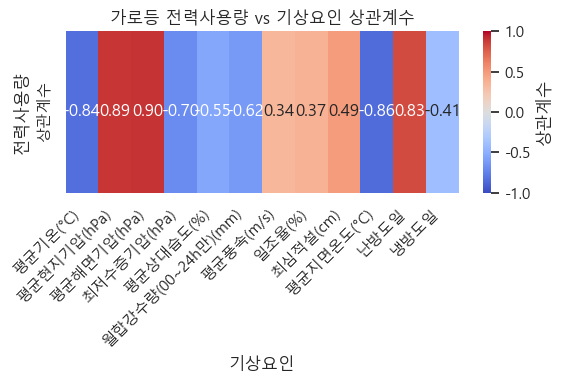

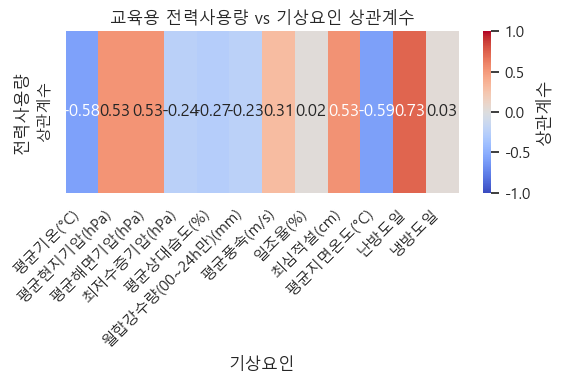

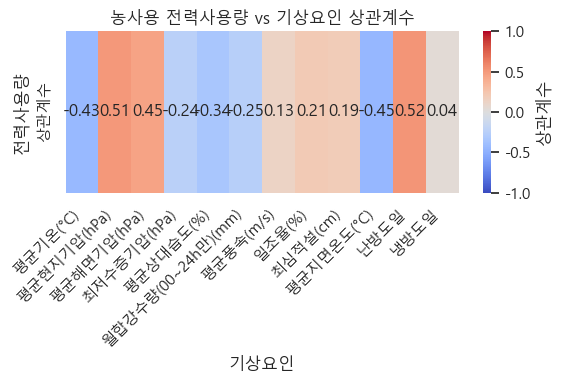

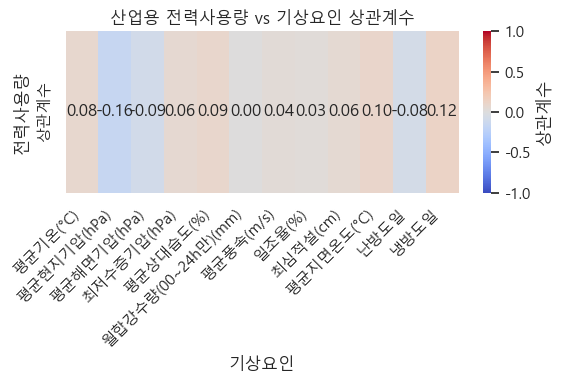

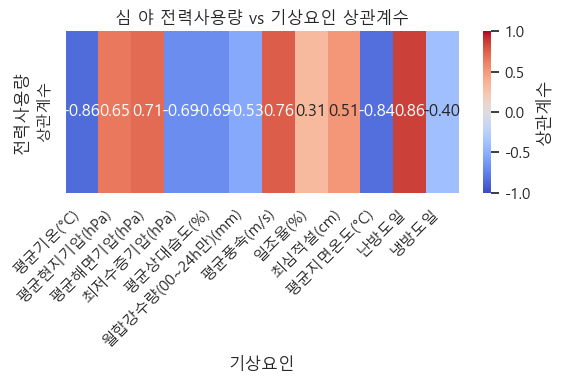

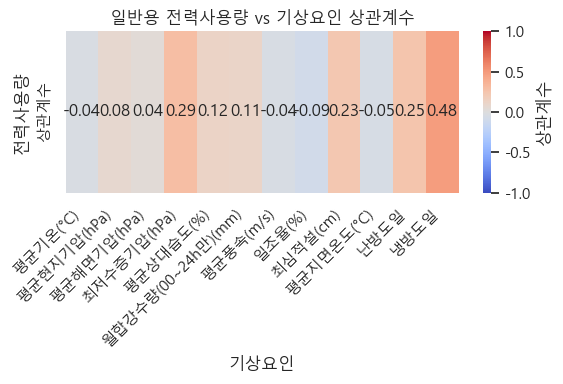

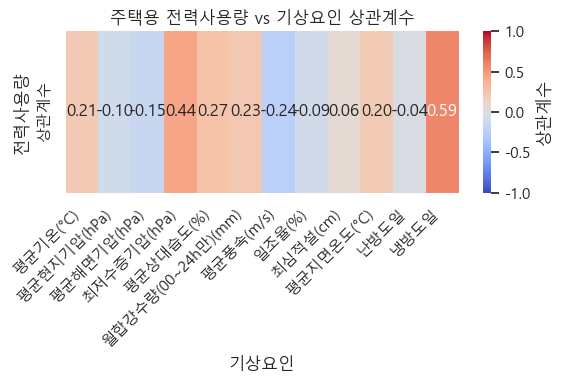

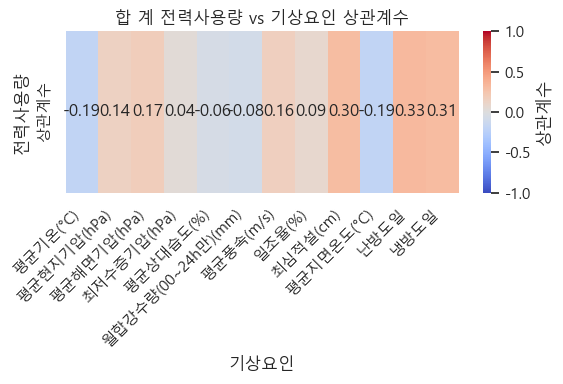

In [373]:
from matplotlib import rc


# 한글 깨짐 방지
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


# 계약종별, 기상요인

contract_types = power_jeolla['계약종별'].unique()
weather_cols = [
    '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '최저수증기압(hPa)',
       '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)',
       '평균지면온도(°C)', '난방도일', '냉방도일'
]


# 계약종별 히트맵 생성

for contract in contract_types:
    # 계약종별 필터
    df_contract = power_jeolla[power_jeolla['계약종별'] == contract].copy()
    
    # 기상 데이터 병합
    df = df_contract.merge(
        jeolla_monthly_weather[['일시'] + weather_cols],
        on='일시',
        how='left'
    )
    
    # 전력사용량과 기상요인 상관계수 계산
    corr_values = [df['전력사용량'].corr(df[col]) for col in weather_cols]
    corr_df = pd.DataFrame(corr_values, index=weather_cols, columns=['상관계수'])
    
    # 
    # 히트맵 시각화
    # 
    plt.figure(figsize=(6,4))
    sns.heatmap(
        corr_df.T,          # 1행 x 10열
        annot=True, fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        cbar_kws={'label':'상관계수'}
    )
    plt.title(f'{contract} 전력사용량 vs 기상요인 상관계수')
    plt.ylabel('전력사용량')
    plt.xlabel('기상요인')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


In [374]:
power_jeolla

,일시,계약종별,전력사용량
0,2015-01,가로등,1.325688e+06
1,2015-01,교육용,2.720462e+06
2,2015-01,농사용,1.425538e+07
3,2015-01,산업용,1.404591e+08
4,2015-01,심 야,9.302026e+06
...,...,...,...
955,2024-12,산업용,1.318278e+08
956,2024-12,심 야,3.067905e+06
957,2024-12,일반용,2.834246e+07
958,2024-12,주택용,1.845733e+07


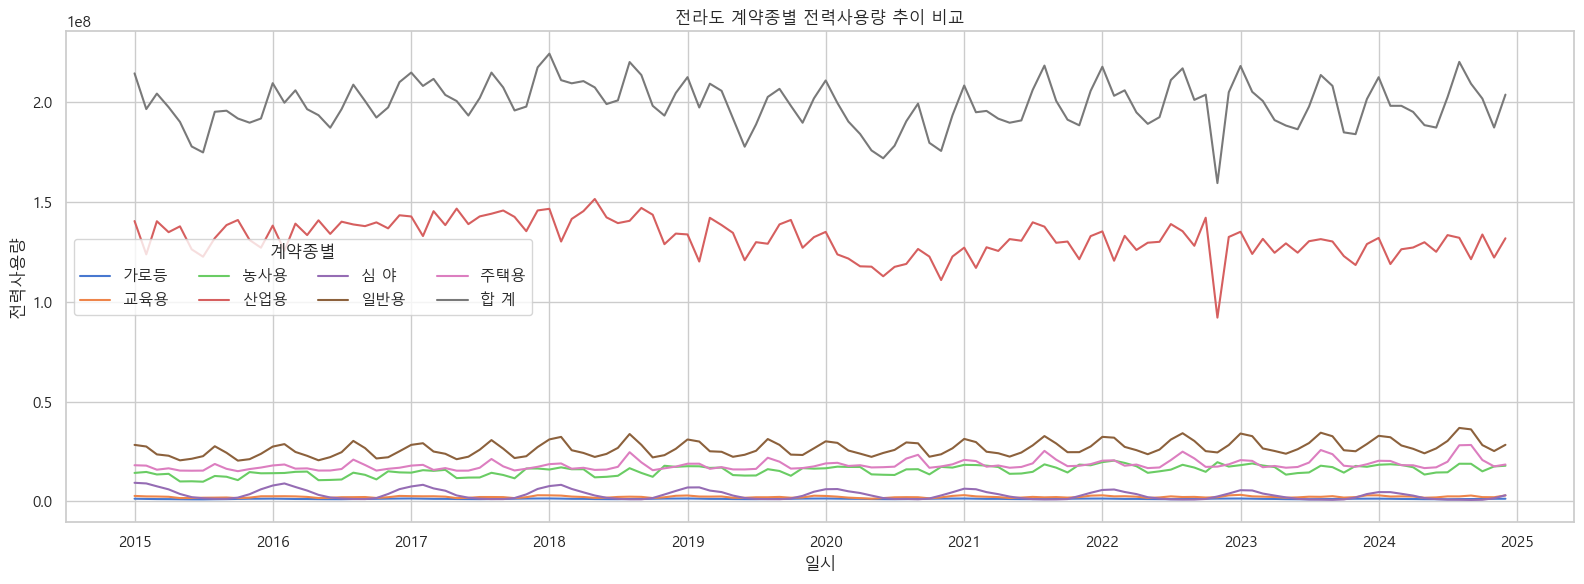

In [375]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 한글 깨짐 방지
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


# 일시 datetime 변환
power_jeolla['일시'] = pd.to_datetime(power_jeolla['일시'], format='%Y-%m')


# 월별 · 계약종별 전력사용량 집계
monthly_contract_power = (
    power_jeolla
    .groupby(['일시', '계약종별'])['전력사용량']
    .sum()
    .reset_index()
)


# 계약종별 목록
contract_types = monthly_contract_power['계약종별'].unique()


# 시각화 ->. 한 그래프에 8개 선
plt.figure(figsize=(16,6))

for contract in contract_types:
    df_c = monthly_contract_power[
        monthly_contract_power['계약종별'] == contract
    ]
    
    plt.plot(
        df_c['일시'],
        df_c['전력사용량'],
        label=contract
    )

plt.title('전라도 계약종별 전력사용량 추이 비교')
plt.xlabel('일시')
plt.ylabel('전력사용량')
plt.legend(title='계약종별', ncol=4)
plt.grid(True)
plt.tight_layout()
plt.show()


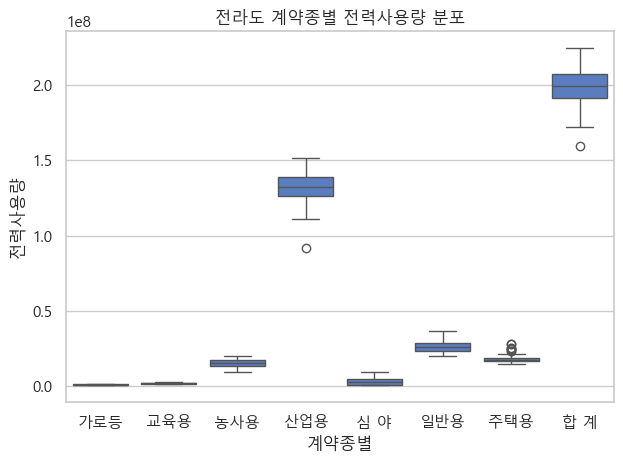

In [376]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rc

# 한글 깨짐 방지
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(
    data=monthly_contract_power,
    x='계약종별',
    y='전력사용량'
)

plt.title('전라도 계약종별 전력사용량 분포')
plt.xlabel('계약종별')
plt.ylabel('전력사용량')
plt.tight_layout()
plt.show()


In [385]:
jeolla_monthly_weather.head()

,일시,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),최저수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),난방도일,냉방도일
0,2015-01,1.554167,1012.750000,1024.525000,2.004167,70.416667,38.391667,2.808333,52.690833,2.162500,2.041667,16.445833,0.0
1,2015-02,2.629167,1010.837500,1022.533333,1.650000,66.666667,28.958333,2.950000,49.338750,0.020833,3.575000,15.370833,0.0
2,2015-03,6.800000,1010.141667,1021.620833,1.504167,60.041667,46.337500,2.591667,63.310000,0.083333,9.133333,11.200000,0.0
3,2015-04,12.741667,1004.729167,1015.879167,2.975000,71.458333,176.320833,2.520833,43.457917,0.000000,14.879167,5.258333,0.0
4,2015-05,17.908333,999.395833,1010.262500,3.995833,65.583333,89.120833,2.354167,60.468333,0.000000,21.937500,0.091667,0.0


In [386]:
jeolla_monthly_weather['일시'] = pd.to_datetime(
    jeolla_monthly_weather['일시']
)


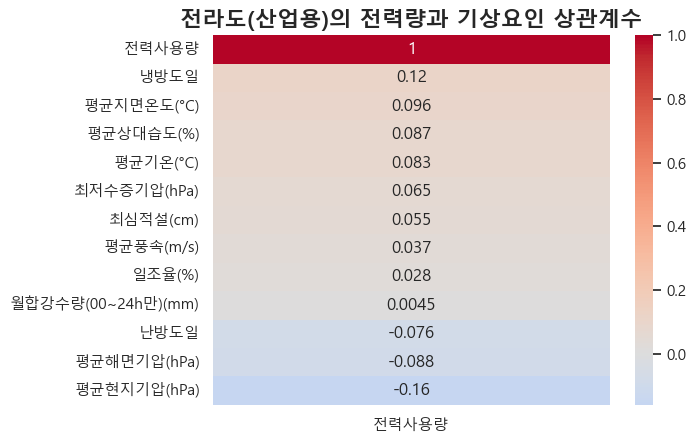

In [388]:
# 한글 깨짐 방지
rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

weather_cols = [
    '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
    '최저수증기압(hPa)', '평균상대습도(%)',
    '월합강수량(00~24h만)(mm)', '평균풍속(m/s)',
    '일조율(%)', '최심적설(cm)', '평균지면온도(°C)',
    '냉방도일', '난방도일'
]

# 산업용만 필터
df_contract = power_jeolla[
    power_jeolla['계약종별'] == '산업용'
].copy()

# 기상 데이터 병합
df = df_contract.merge(
    jeolla_monthly_weather[['일시'] + weather_cols],
    on='일시'
)

# 상관계수 계산
corr = df[
    ['전력사용량'] + weather_cols
].corr()

# 전력사용량 기준 정렬
corr_power = corr[['전력사용량']].sort_values(
    by='전력사용량',
    ascending=False
)

# 히트맵 
sns.heatmap(corr_power, annot=True, cmap='coolwarm', center=0)
plt.title('전라도(산업용)의 전력량과 기상요인 상관계수', fontweight='bold', fontsize=16)
plt.show()


In [389]:
'''
['지점명', '일시', '지점', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', '연도', '시도', '시군구', '계약종별', '월', '전력사용량',
       'CDD', 'HDD']
       '''

"\n['지점명', '일시', '지점', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',\n       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',\n       '최심적설(cm)', '평균지면온도(°C)', '연도', '시도', '시군구', '계약종별', '월', '전력사용량',\n       'CDD', 'HDD']\n       "

In [390]:
jeolla_industry = df_contract.merge(
    jeolla_monthly_weather[['일시'] + weather_cols],
    on='일시'
)

In [391]:
jeolla_industry.head()

,일시,계약종별,전력사용량,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),최저수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),냉방도일,난방도일
0,2015-01-01,산업용,1.404591e+08,1.554167,1012.750000,1024.525000,2.004167,70.416667,38.391667,2.808333,52.690833,2.162500,2.041667,0.0,16.445833
1,2015-02-01,산업용,1.237641e+08,2.629167,1010.837500,1022.533333,1.650000,66.666667,28.958333,2.950000,49.338750,0.020833,3.575000,0.0,15.370833
2,2015-03-01,산업용,1.403663e+08,6.800000,1010.141667,1021.620833,1.504167,60.041667,46.337500,2.591667,63.310000,0.083333,9.133333,0.0,11.200000
3,2015-04-01,산업용,1.348862e+08,12.741667,1004.729167,1015.879167,2.975000,71.458333,176.320833,2.520833,43.457917,0.000000,14.879167,0.0,5.258333
4,2015-05-01,산업용,1.378044e+08,17.908333,999.395833,1010.262500,3.995833,65.583333,89.120833,2.354167,60.468333,0.000000,21.937500,0.0,0.091667


In [ ]:
# !pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------------- ---------------------- 4.2/9.5 MB 25.0 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.5 MB 14.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 11.5 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 11.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.5 MB 8.0 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.5 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 6.7 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- 

In [ ]:
import statsmodels.api as sm
import numpy as np

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rc("font", family = "Malgun Gothic")
# sns.set(font="Malgun Gothic", 
# rc={"axes.unicode_minus":False}, style='white')

# 한글 폰트 설정 (Mac)
plt.rc('font', family='AppleGothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
'''
['지점명', '일시', '지점', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '평균수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', '연도', '시도', '시군구', '계약종별', '월', '전력사용량',
       'CDD', 'HDD']
       '''

In [ ]:
jeolla_industry

,일시,계약종별,전력사용량,평균기온(°C),평균현지기압(hPa),평균해면기압(hPa),최저수증기압(hPa),평균상대습도(%),월합강수량(00~24h만)(mm),평균풍속(m/s),일조율(%),최심적설(cm),평균지면온도(°C),난방도일,냉방도일
0,2015-01,합 계,2.144571e+08,1.554167,1012.750000,1024.525000,2.004167,70.416667,38.391667,2.808333,52.690833,2.162500,2.041667,16.445833,0.000000
1,2015-02,합 계,1.965745e+08,2.629167,1010.837500,1022.533333,1.650000,66.666667,28.958333,2.950000,49.338750,0.020833,3.575000,15.370833,0.000000
2,2015-03,합 계,2.043303e+08,6.800000,1010.141667,1021.620833,1.504167,60.041667,46.337500,2.591667,63.310000,0.083333,9.133333,11.200000,0.000000
3,2015-04,합 계,1.975300e+08,12.741667,1004.729167,1015.879167,2.975000,71.458333,176.320833,2.520833,43.457917,0.000000,14.879167,5.258333,0.000000
4,2015-05,합 계,1.901389e+08,17.908333,999.395833,1010.262500,3.995833,65.583333,89.120833,2.354167,60.468333,0.000000,21.937500,0.091667,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,2024-08,합 계,2.202233e+08,28.260870,998.078261,1007.039130,22.100000,80.565217,72.091304,1.756522,61.620000,0.000000,32.204348,0.000000,4.260870
116,2024-09,합 계,2.092775e+08,25.808696,1003.295652,1012.386957,14.547826,80.434783,248.617391,1.700000,53.909565,0.000000,28.747826,0.000000,1.808696
117,2024-10,합 계,2.018257e+08,17.165217,1009.878261,1019.326087,7.773913,79.956522,116.713043,1.873913,42.467826,0.000000,18.726087,0.834783,0.000000
118,2024-11,합 계,1.873276e+08,10.882609,1012.247826,1022.021739,2.334783,72.478261,82.130435,2.278261,50.154348,0.000000,11.208696,7.117391,0.000000


In [ ]:
jeolla_industry.columns

Index(['일시', '계약종별', '전력사용량', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '최저수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', '난방도일', '냉방도일'],
      dtype='object')

In [ ]:
jeolla_industry = jeolla_industry[['일시', '계약종별', '전력사용량', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)',
       '최저수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)',
       '최심적설(cm)', '평균지면온도(°C)', '난방도일', '냉방도일']]
jeolla_industry.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   일시                  120 non-null    object 
 1   계약종별                120 non-null    object 
 2   전력사용량               120 non-null    float64
 3   평균기온(°C)            120 non-null    float64
 4   평균현지기압(hPa)         120 non-null    float64
 5   평균해면기압(hPa)         120 non-null    float64
 6   최저수증기압(hPa)         120 non-null    float64
 7   평균상대습도(%)           120 non-null    float64
 8   월합강수량(00~24h만)(mm)  120 non-null    float64
 9   평균풍속(m/s)           120 non-null    float64
 10  일조율(%)              120 non-null    float64
 11  최심적설(cm)            120 non-null    float64
 12  평균지면온도(°C)          120 non-null    float64
 13  난방도일                120 non-null    float64
 14  냉방도일                120 non-null    float64
dtypes: float64(13), object(2)
memory usage: 14.2+ KB


In [394]:
df = jeolla_industry.copy()

df['일시'] = pd.to_datetime(df['일시'])
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month


In [395]:
df = df.rename(columns={'month': '월'})

df_encoded = pd.get_dummies(
    df,
    columns=['월'],
    drop_first=True,
    dtype=int
)


In [396]:
x_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
] + month_cols


In [397]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
]

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])


In [398]:
df_encoded['평균기온_sq'] = df_encoded['평균기온(°C)'] ** 2


In [399]:
import statsmodels.api as sm

X = sm.add_constant(df_encoded[x_cols + ['평균기온_sq']])
y = df_encoded['전력사용량']


KeyError: "[' 1월 ', ' 2월 ', ' 3월 ', ' 4월 ', ' 5월 ', ' 6월 ', ' 7월 ', ' 8월 ', ' 9월 ', ' 10월 ', ' 11월 ', ' 12월 '] not in index"

In [401]:
print(df_encoded.columns.tolist())

['일시', '계약종별', '전력사용량', '평균기온(°C)', '평균현지기압(hPa)', '평균해면기압(hPa)', '최저수증기압(hPa)', '평균상대습도(%)', '월합강수량(00~24h만)(mm)', '평균풍속(m/s)', '일조율(%)', '최심적설(cm)', '평균지면온도(°C)', '냉방도일', '난방도일', 'year', '월_2', '월_3', '월_4', '월_5', '월_6', '월_7', '월_8', '월_9', '월_10', '월_11', '월_12', '평균기온_sq']


In [402]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler


# 1. 데이터 복사 + 연/월 분리
df = jeolla_industry.copy()

df['일시'] = pd.to_datetime(df['일시'])
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month

# 2. 월 더미 변수 생성 (1월 기준)
df_encoded = pd.get_dummies(
    df,
    columns=['month'],
    drop_first=True,
    dtype=int
)

# 월 더미 컬럼 자동 수집
month_cols = [c for c in df_encoded.columns if c.startswith('month_')]


# 3. 독립변수(X) 정의
x_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
] + month_cols


# 4. 수치형 변수 표준화 (더미 제외)
numeric_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
]

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])


# 5. 비선형성 추가 (기온 제곱항)
df_encoded['평균기온_sq'] = df_encoded['평균기온(°C)'] ** 2


# 6. X, y 구성
X = sm.add_constant(df_encoded[x_cols + ['평균기온_sq']])
y = df_encoded['전력사용량']


# 7. Gamma GLM 적합
model = sm.GLM(
    y,
    X,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                  전력사용량   No. Observations:                  120
Model:                            GLM   Df Residuals:                      101
Model Family:                   Gamma   Df Model:                           18
Link Function:                    log   Scale:                       0.0030694
Method:                          IRLS   Log-Likelihood:                -2059.3
Date:                Tue, 03 Feb 2026   Deviance:                      0.32369
Time:                        17:38:47   Pearson chi2:                    0.310
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5276
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          18.6713      0.083    223.783      

c:\Users\skgpf\miniconda3\envs\mlstudy_env\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


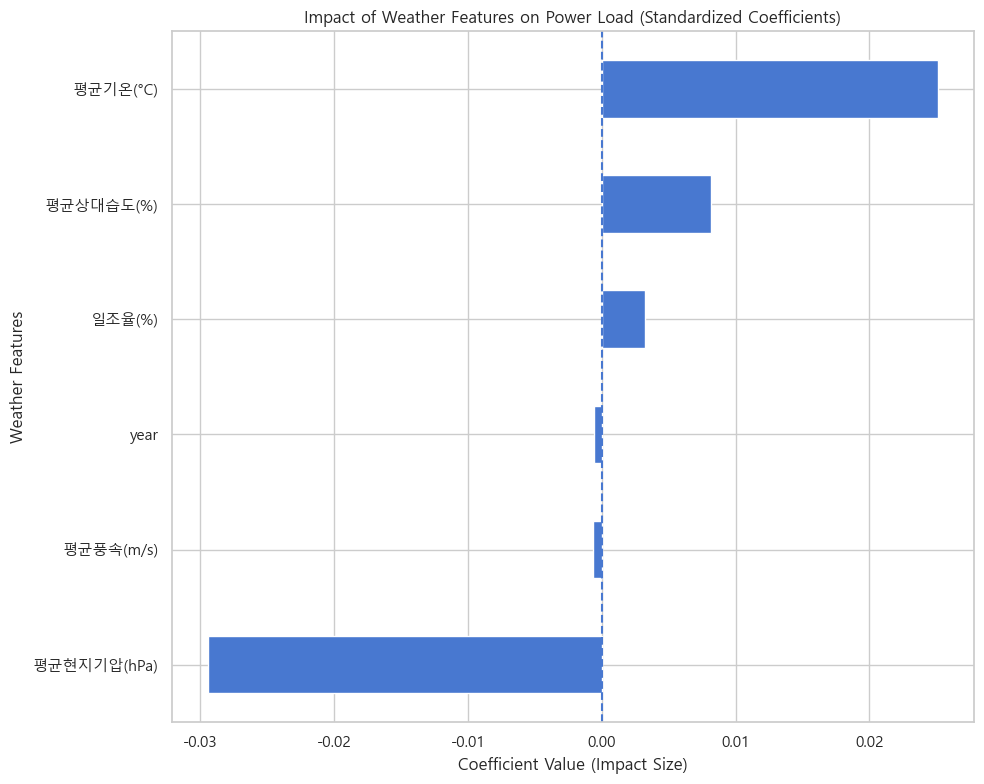

In [ ]:
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False


# 1. 제거할 변수 목록 정의
drop_cols = ['const', '평균기온_sq'] + month_cols

# 실제 params에 존재하는 컬럼만 제거
weather_impact = model.params.drop(
    labels=[c for c in drop_cols if c in model.params.index]
)


# 2. 계수 크기 기준 정렬
weather_impact = weather_impact.sort_values()


# 3. 시각화
plt.figure(figsize=(10, 8))
weather_impact.plot(kind='barh')
plt.axvline(0, linestyle='--')
plt.title('Impact of Weather Features on Power Load (Standardized Coefficients)')
plt.xlabel('Coefficient Value (Impact Size)')
plt.ylabel('Weather Features')
plt.tight_layout()
plt.show()


In [403]:
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 1. 데이터 복사 + 연/월 분리
df = jeolla_industry.copy()
df['일시'] = pd.to_datetime(df['일시'])
df['year'] = df['일시'].dt.year
df['month'] = df['일시'].dt.month

# month 컬럼 이름을 '월'로 변경
df = df.rename(columns={'month': '월'})

# 2. 월 더미 변수 생성 (1월 기준)
df_encoded = pd.get_dummies(
    df,
    columns=['월'],  # 컬럼 이름 '월'
    drop_first=True,  # 1월 기준
    dtype=int
)

# 월 더미 컬럼 자동 수집
month_cols = [c for c in df_encoded.columns if c.startswith('월_')]
print("월 더미 컬럼:", month_cols)  # ['월_2', '월_3', ..., '월_12']

# 3. 독립변수(X) 정의
x_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
] + month_cols

# 4. 수치형 변수 표준화 (더미 제외)
numeric_cols = [
    '평균기온(°C)',
    '평균상대습도(%)',
    '평균현지기압(hPa)',
    '평균풍속(m/s)',
    '일조율(%)',
    'year'
]

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# 5. 비선형성 추가 (기온 제곱항)
df_encoded['평균기온_sq'] = df_encoded['평균기온(°C)'] ** 2

# 6. X, y 구성
X = sm.add_constant(df_encoded[x_cols + ['평균기온_sq']])
y = df_encoded['전력사용량']

# 7. Gamma GLM 적합
model = sm.GLM(
    y,
    X,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(model.summary())


월 더미 컬럼: ['월_2', '월_3', '월_4', '월_5', '월_6', '월_7', '월_8', '월_9', '월_10', '월_11', '월_12']
                 Generalized Linear Model Regression Results                  
Dep. Variable:                  전력사용량   No. Observations:                  120
Model:                            GLM   Df Residuals:                      101
Model Family:                   Gamma   Df Model:                           18
Link Function:                    log   Scale:                       0.0030694
Method:                          IRLS   Log-Likelihood:                -2059.3
Date:                Tue, 03 Feb 2026   Deviance:                      0.32369
Time:                        17:41:40   Pearson chi2:                    0.310
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5276
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

c:\Users\skgpf\miniconda3\envs\mlstudy_env\Lib\site-packages\statsmodels\genmod\families\links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


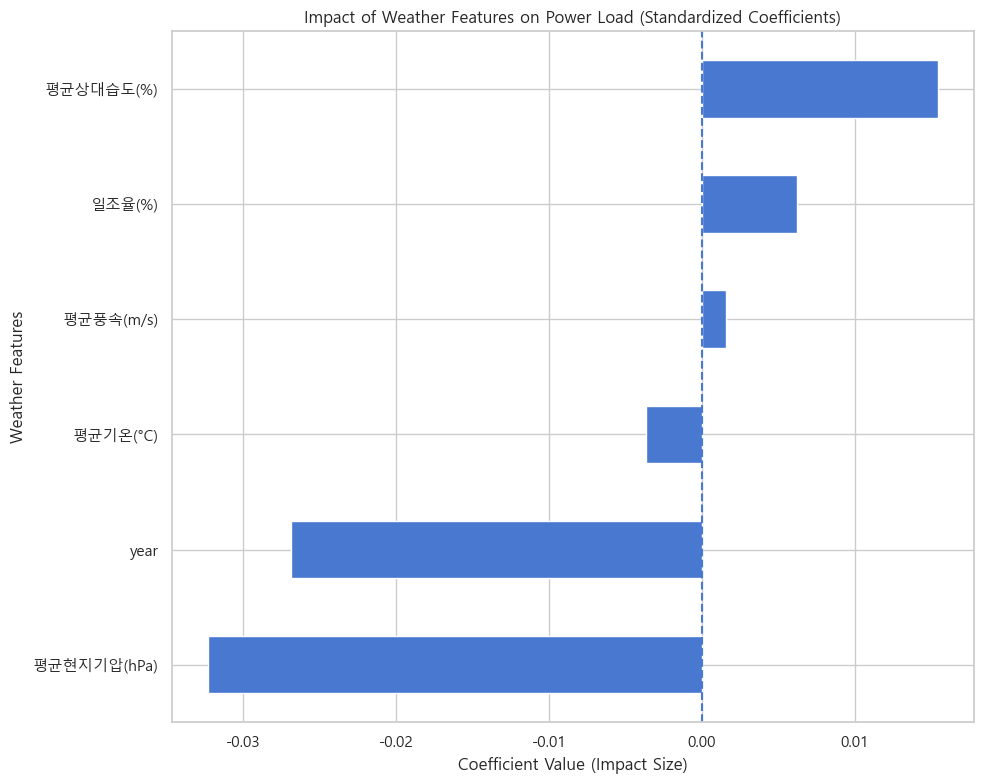

In [404]:
# 1. 제거할 변수 목록 정의
drop_cols = ['const', '평균기온_sq'] + month_cols

# 실제 params에 존재하는 컬럼만 제거
weather_impact = model.params.drop(
    labels=[c for c in drop_cols if c in model.params.index]
)


# 2. 계수 크기 기준 정렬
weather_impact = weather_impact.sort_values()


# 3. 시각화
plt.figure(figsize=(10, 8))
weather_impact.plot(kind='barh')
plt.axvline(0, linestyle='--')
plt.title('Impact of Weather Features on Power Load (Standardized Coefficients)')
plt.xlabel('Coefficient Value (Impact Size)')
plt.ylabel('Weather Features')
plt.tight_layout()
plt.show()


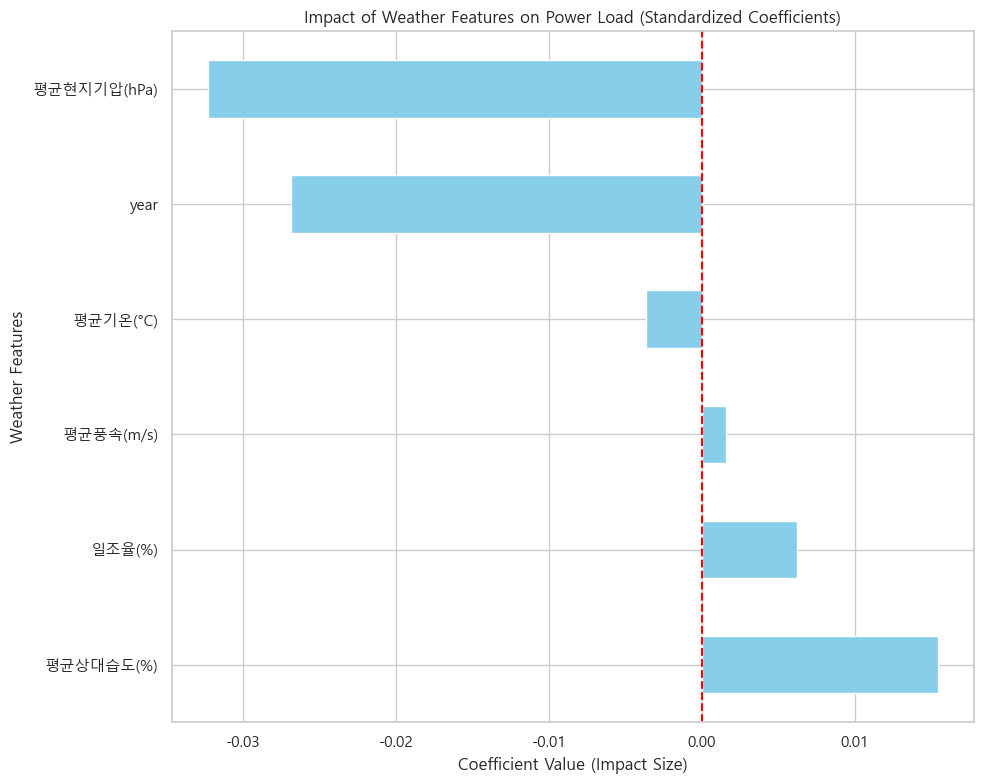

In [ ]:
import matplotlib.pyplot as plt

# 제외할 컬럼 지정
# 상수항, 월별 더미, 파생 변수 등
exclude_cols = ['const'] + month_cols + ['평균기온_sq']  # 필요하면 추가 가능

# 2️⃣ 모델 계수 중 주요 날씨 변수만 추출
weather_impact = model.params.drop(exclude_cols)

# 3️⃣ 영향 크기 순으로 정렬
weather_impact = weather_impact.sort_values(ascending=False)

# 4️⃣ 시각화
plt.figure(figsize=(10, 8))
weather_impact.plot(kind='barh', color='skyblue')
plt.axvline(0, color='red', linestyle='--')  # 계수 0 기준선
plt.title('Impact of Weather Features on Power Load (Standardized Coefficients)')
plt.xlabel('Coefficient Value (Impact Size)')
plt.ylabel('Weather Features')
plt.tight_layout()
plt.show()
